# Bike Availability Prediction Notebook Skeleton

This notebook adapts it to predict **`num_bikes_available`**.

## Workflow
1. Load data  
2. Inspect data  
3. Clean data  
4. Feature engineering / feature selection  
5. Train-test split  
6. Train multiple regression models  
7. Evaluate with **MAE** and **R²**  
8. Compare models and choose the best  
9. Save the best model

## 1. Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

This code imports the libraries needed for data processing, visualisation, model training, evaluation, and saving the final model.


## 2. Load the dataset

Replace the file path below with your actual dataset file.

In [4]:
df = pd.read_csv("final_merged_data.csv")
df.head()

,last_reported,station_id,num_bikes_available,num_docks_available,is_installed,is_renting,is_returning,name,address,lat,...,min_humidity_quality_indicator,min_relative_humidity_percent,humidity_std_quality_indicator,relative_humidity_std_deviation,max_pressure_quality_indicator,max_barometric_pressure_hpa,min_pressure_quality_indicator,min_barometric_pressure_hpa,pressure_std_quality_indicator,barometric_pressure_std_deviation
0,2024-12-01 00:10:00,10,15,1,True,True,True,DAME STREET,Dame Street,53.344006,...,0,83.2,0,0.284,0,1002.56,0,1002.26,0,0.083
1,2024-12-01 00:10:00,100,17,8,True,True,True,HEUSTON BRIDGE (SOUTH),Heuston Bridge (South),53.347107,...,0,83.2,0,0.284,0,1002.56,0,1002.26,0,0.083
2,2024-12-01 00:10:00,109,20,9,True,True,True,BUCKINGHAM STREET LOWER,Buckingham Street Lower,53.353333,...,0,83.2,0,0.284,0,1002.56,0,1002.26,0,0.083
3,2024-12-01 00:10:00,11,1,29,True,True,True,EARLSFORT TERRACE,Earlsfort Terrace,53.334293,...,0,83.2,0,0.284,0,1002.56,0,1002.26,0,0.083
4,2024-12-01 00:10:00,114,4,36,True,True,True,WILTON TERRACE (PARK),Wilton Terrace (Park),53.333652,...,0,83.2,0,0.284,0,1002.56,0,1002.26,0,0.083


## 3. Inspect the data

In [6]:
print(df.shape)
df.info()

(298946, 78)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 298946 entries, 0 to 298945
Data columns (total 78 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   last_reported                           298946 non-null  object 
 1   station_id                              298946 non-null  int64  
 2   num_bikes_available                     298946 non-null  int64  
 3   num_docks_available                     298946 non-null  int64  
 4   is_installed                            298946 non-null  bool   
 5   is_renting                              298946 non-null  bool   
 6   is_returning                            298946 non-null  bool   
 7   name                                    298946 non-null  object 
 8   address                                 298946 non-null  object 
 9   lat                                     298946 non-null  float64
 10  lon                            

In [5]:
df.describe(include="all")

,last_reported,station_id,num_bikes_available,num_docks_available,is_installed,is_renting,is_returning,name,address,lat,...,min_humidity_quality_indicator,min_relative_humidity_percent,humidity_std_quality_indicator,relative_humidity_std_deviation,max_pressure_quality_indicator,max_barometric_pressure_hpa,min_pressure_quality_indicator,min_barometric_pressure_hpa,pressure_std_quality_indicator,barometric_pressure_std_deviation
count,298946,298946.000000,298946.000000,298946.000000,298946,298946,298946,298946,298946,298946.000000,...,298946.0,298946.000000,298946.0,298946.000000,298946.0,298946.000000,298946.0,298946.000000,298946.0,298946.000000
unique,4433,NaN,NaN,NaN,1,1,1,115,115,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2024-12-11 00:30:00,NaN,NaN,NaN,True,True,True,CHARLEMONT PLACE,Charlemont Street,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,115,NaN,NaN,NaN,298946,298946,298946,3336,3336,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,57.967138,12.204733,19.335198,NaN,NaN,NaN,NaN,NaN,53.345521,...,0.0,83.548719,0.0,0.377589,0.0,1014.855870,0.0,1014.689671,0.0,0.045488
std,NaN,33.958176,9.761814,11.001506,NaN,NaN,NaN,NaN,NaN,0.007538,...,0.0,8.160979,0.0,0.232676,0.0,11.823993,0.0,11.894264,0.0,0.038661
min,NaN,1.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,53.330090,...,0.0,52.970000,0.0,0.072000,0.0,975.060000,0.0,975.010000,0.0,0.004000
25%,NaN,28.000000,4.000000,11.000000,NaN,NaN,NaN,NaN,NaN,53.339764,...,0.0,78.910000,0.0,0.230000,0.0,1006.010000,0.0,1005.770000,0.0,0.022000
50%,NaN,57.000000,11.000000,19.000000,NaN,NaN,NaN,NaN,NaN,53.345203,...,0.0,84.700000,0.0,0.314000,0.0,1017.210000,0.0,1017.060000,0.0,0.034000
75%,NaN,88.000000,19.000000,28.000000,NaN,NaN,NaN,NaN,NaN,53.350292,...,0.0,89.000000,0.0,0.450000,0.0,1022.660000,0.0,1022.570000,0.0,0.057000


This command provides a summary of all columns in the dataset, 
including numerical and categorical features. It helps to understand 
data distribution and identify potential issues such as missing values or outliers.

In [6]:
df.isnull().sum().sort_values(ascending=False).head(20)

last_reported                     0
station_id                        0
num_bikes_available               0
num_docks_available               0
is_installed                      0
is_renting                        0
is_returning                      0
name                              0
address                           0
lat                               0
lon                               0
capacity                          0
stno                              0
year                              0
month                             0
day                               0
hour                              0
minute                            0
max_air_temp_quality_indicator    0
max_air_temperature_celsius       0
dtype: int64

This code checks the number of missing values in each column, sorts them in descending order, and displays the top 20 columns with the most missing values.

## 4. Data cleaning

This section removes duplicates and drops columns that are not useful for prediction.

### Columns to remove
- direct timestamp text column if you already have year/month/day/hour/minute
- name/address identifiers
- boolean service status columns if they are not useful
- all `quality_indicator` columns
- columns you decide would leak the target

In [7]:
# remove duplicate rows
df = df.drop_duplicates().copy()

df["last_reported"] = pd.to_datetime(df["last_reported"])
df= df.sort_values("last_reported").reset_index(drop=True)

# columns to drop
drop_cols = [
    "name",
    "address",
    "stno",
    "is_installed",
    "is_renting",
    "is_returning",
    "num_docks_available",
    "capacity"
]

# drop all quality indicator columns automatically
drop_cols += [col for col in df.columns if "quality_indicator" in col]

# keep only columns that actually exist
drop_cols = [col for col in drop_cols if col in df.columns]

df = df.drop(columns=drop_cols)

print("Remaining columns:", len(df.columns))
df.head()

Remaining columns: 40


,last_reported,station_id,num_bikes_available,lat,lon,year,month,day,hour,minute,...,earth_temperature_std_deviation_50cm,max_earth_temperature_100cm_celsius,min_earth_temperature_100cm_celsius,earth_temperature_std_deviation_100cm,max_relative_humidity_percent,min_relative_humidity_percent,relative_humidity_std_deviation,max_barometric_pressure_hpa,min_barometric_pressure_hpa,barometric_pressure_std_deviation
0,2024-12-01 00:10:00,10,15,53.344006,-6.266802,2024,12,1,0,10,...,0.008,9.87,9.83,0.008,84.3,83.2,0.284,1002.56,1002.26,0.083
1,2024-12-01 00:10:00,53,7,53.337130,-6.260590,2024,12,1,0,10,...,0.008,9.87,9.83,0.008,84.3,83.2,0.284,1002.56,1002.26,0.083
2,2024-12-01 00:10:00,54,12,53.336020,-6.262980,2024,12,1,0,10,...,0.008,9.87,9.83,0.008,84.3,83.2,0.284,1002.56,1002.26,0.083
3,2024-12-01 00:10:00,55,2,53.334030,-6.260714,2024,12,1,0,10,...,0.008,9.87,9.83,0.008,84.3,83.2,0.284,1002.56,1002.26,0.083
4,2024-12-01 00:10:00,57,2,53.339630,-6.243778,2024,12,1,0,10,...,0.008,9.87,9.83,0.008,84.3,83.2,0.284,1002.56,1002.26,0.083


After data cleaning, the remaining features include station information (station_id, latitude, longitude), time-related variables (year, month, day, hour), and weather-related variables such as temperature, humidity, and pressure. The target variable is the number of available bikes.

在数据清洗之后，剩余的特征包括站点信息（station_id、纬度、经度）、时间相关变量（年、月、日、小时）以及天气相关变量（如温度、湿度和气压）。目标变量是可用自行车的数量

## 5. Feature engineering

If needed, create extra time features here.

For example, if you still want `day_of_week`, you can derive it from a datetime column.

In [8]:
# OPTIONAL: create day_of_week if you have a datetime column
# df["last_reported"] = pd.to_datetime(df["last_reported"])
# df["day_of_week"] = df["last_reported"].dt.dayofweek
df["date"] = pd.to_datetime(df[["year", "month", "day"]])
df["day_of_week"] = df["date"].dt.dayofweek
df["rush_hour"] = df["hour"].apply(
    lambda x: 1 if (7 <= x <= 9) or (16 <= x <= 19) else 0
)
df.head(3270)

,last_reported,station_id,num_bikes_available,lat,lon,year,month,day,hour,minute,...,earth_temperature_std_deviation_100cm,max_relative_humidity_percent,min_relative_humidity_percent,relative_humidity_std_deviation,max_barometric_pressure_hpa,min_barometric_pressure_hpa,barometric_pressure_std_deviation,date,day_of_week,rush_hour
0,2024-12-01 00:10:00,10,15,53.344006,-6.266802,2024,12,1,0,10,...,0.008,84.3,83.2,0.284,1002.56,1002.26,0.083,2024-12-01,6,0
1,2024-12-01 00:10:00,53,7,53.337130,-6.260590,2024,12,1,0,10,...,0.008,84.3,83.2,0.284,1002.56,1002.26,0.083,2024-12-01,6,0
2,2024-12-01 00:10:00,54,12,53.336020,-6.262980,2024,12,1,0,10,...,0.008,84.3,83.2,0.284,1002.56,1002.26,0.083,2024-12-01,6,0
3,2024-12-01 00:10:00,55,2,53.334030,-6.260714,2024,12,1,0,10,...,0.008,84.3,83.2,0.284,1002.56,1002.26,0.083,2024-12-01,6,0
4,2024-12-01 00:10:00,57,2,53.339630,-6.243778,2024,12,1,0,10,...,0.008,84.3,83.2,0.284,1002.56,1002.26,0.083,2024-12-01,6,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3265,2024-12-01 08:50:00,43,2,53.330090,-6.268044,2024,12,1,8,50,...,0.008,88.3,86.6,0.429,1000.43,1000.34,0.019,2024-12-01,6,1
3266,2024-12-01 08:50:00,40,19,53.348300,-6.266651,2024,12,1,8,50,...,0.008,88.3,86.6,0.429,1000.43,1000.34,0.019,2024-12-01,6,1
3267,2024-12-01 08:50:00,4,10,53.346874,-6.272976,2024,12,1,8,50,...,0.008,88.3,86.6,0.429,1000.43,1000.34,0.019,2024-12-01,6,1
3268,2024-12-01 08:50:00,17,7,53.340800,-6.267732,2024,12,1,8,50,...,0.008,88.3,86.6,0.429,1000.43,1000.34,0.019,2024-12-01,6,1


Additional time features such as day_of_week can be derived from existing date information to improve model performance.

## 6. Feature selection

The target is:

- `num_bikes_available`

The features below are a **good starter set** based on your current dataset.
You can later add/remove columns and compare performance.

In [9]:
target = "num_bikes_available"

features = [
    "station_id",
    "hour",
    "month",
    "year",
    "lat",
    "lon",
    "day_of_week",
    "rush_hour",
    "max_air_temperature_celsius",  
    "air_temperature_std_deviation",
    "max_relative_humidity_percent",
   
    
]

# keep only features that exist in df
features = [col for col in features if col in df.columns]

X = df[features]
y = df[target]

print("Features used:")
print(features)
print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features used:
['station_id', 'hour', 'month', 'year', 'lat', 'lon', 'day_of_week', 'rush_hour', 'max_air_temperature_celsius', 'air_temperature_std_deviation', 'max_relative_humidity_percent']

X shape: (298946, 11)
y shape: (298946,)


This code defines num_bikes_available as the target variable to be predicted. It then selects a set of relevant input features, including station information, time-related features, and weather-related variables. After ensuring that all selected features exist in the dataset, it creates the feature matrix X and the target vector y. Finally, it prints the selected features and the shapes of X and y to confirm that the data has been prepared correctly for model training.

The output shows that the dataset contains 298,946 samples and 15 selected features. These features include station information, time-related variables, and weather conditions. The feature matrix X and target vector y have matching sizes, indicating that the data is properly prepared for model training.

这段代码首先将 num_bikes_available 定义为目标变量，即模型需要预测的可用自行车数量。然后选取站点信息、时间特征和天气特征作为输入特征，包括 station_id、hour、month、year、lat、lon、day_of_week、rush_hour 以及温度、湿度和气压相关变量。接着，代码检查这些特征是否真实存在于数据集中，并构建特征矩阵 X 和目标变量 y。最后输出所使用的特征名称以及 X 和 y 的维度，以确认数据已经正确准备好用于模型训练。
该输出表明，最终用于建模的数据包含 298,946 条样本 和 15 个特征变量。这些特征涵盖了站点信息、时间特征以及天气相关变量。特征矩阵 X 与目标变量 y 的样本数量一致，说明数据已经正确整理，可以直接用于后续的模型训练。

## 7. Correlation check

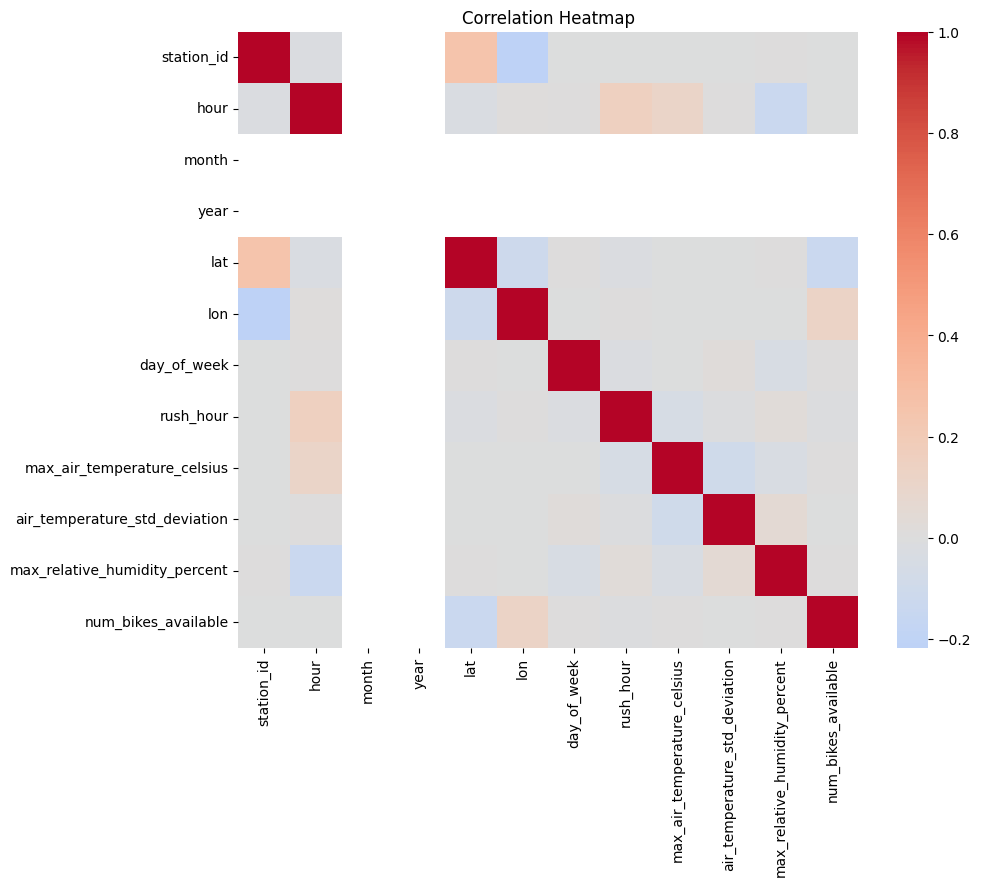

In [10]:
corr_cols = features + [target]
corr_matrix = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

This code computes the correlation matrix for the selected features and the target variable, and visualises it using a heatmap. It helps identify which features are more strongly related to bike availability and whether some features are highly correlated with each other.

The correlation heatmap shows that most features have only weak to moderate relationships with the target variable, indicating that bike availability is influenced by multiple factors rather than a single strong predictor.
Strong correlations are observed between similar features such as maximum and minimum temperature, humidity, and pressure, suggesting redundancy. Therefore, some of these features can be removed to reduce multicollinearity and improve model performance.

Highly correlated features such as minimum temperature, humidity, and pressure were removed to reduce redundancy. Only one representative feature from each group was retained to improve model stability and reduce multicollinearity.

The simplified features are:

features = [
    "station_id",
    "hour",
    "month",
    "year",
    "lat",
    "lon",
    "day_of_week",
    "rush_hour",

    "max_air_temperature_celsius",
    "air_temperature_std_deviation",
    "max_relative_humidity_percent",
]

During feature selection, I experimented with removing highly correlated features to reduce redundancy and simplify the model. However, the results showed that keeping these features produced a higher R² in the Random Forest model. This suggests that, although the features are correlated, they still provide useful additional information for the tree-based model. Therefore, the final model retains these features to achieve better predictive performance.

这段代码用于计算所选特征和目标变量之间的相关性，并通过热力图进行可视化展示。它可以帮助识别哪些特征与可用自行车数量关系更强，以及哪些特征之间存在较强相关性，从而为后续特征选择提供参考。
相关性热力图表明，大多数特征与目标变量之间的相关性较弱到中等，说明自行车数量受到多种因素共同影响，而不是由单一特征决定。同时，一些特征之间（如最大值和最小值的温度、湿度和气压）存在较强相关性，说明存在冗余信息，因此可以适当删除部分特征以减少多重共线性并提高模型性能。
删除了冗余特征，min_air_temperature_celsius, min_relative_humidity_percent, min_barometric_pressure_hpa


## 8. Train-test split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (239156, 11)
X_test : (59790, 11)
y_train: (239156,)
y_test : (59790,)


This code splits the feature matrix X and target vector y into training and testing sets, using 80% of the data for training and 20% for testing. The training set is used to fit the model, while the test set is used to evaluate its performance. The parameter random_state=42 ensures reproducibility, and the shapes are printed to confirm that the split was successful.

这段代码将特征数据 X 和目标变量 y 按照 80% 和 20% 的比例划分为训练集和测试集。其中，训练集用于模型训练，测试集用于模型评估。random_state=42 用于保证每次运行时划分结果一致，最后通过打印各数据集的维度来确认划分是否成功

## 9. Model 1 - Linear Regression

In [12]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression MAE:", lr_mae)
print("Linear Regression R² :", lr_r2)

Linear Regression MAE: 7.989576965409656
Linear Regression R² : 0.03547548875293871


This code creates a Linear Regression model and trains it using the training data. The trained model is then used to make predictions on the test set. Its performance is evaluated using Mean Absolute Error (MAE) and R² score, and the results are printed to assess how well the model predicts bike availability.

这段代码首先创建一个线性回归模型，并使用训练集对模型进行训练。然后利用训练好的模型对测试集进行预测，并通过平均绝对误差（MAE）和决定系数（R²）来评估模型性能。最后输出评估结果，用于判断线性回归模型对自行车数量预测的效果。
线性回归模型的 MAE 约为 7.99，R² 约为 0.035，说明模型预测误差较大且拟合效果较差。这表明线性回归难以捕捉数据中的复杂关系。由于自行车数量受到时间和天气等非线性因素影响较大，因此线性回归模型并不适合该任务

## 10. Model 2 - Decision Tree Regressor

In [13]:
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_mae = mean_absolute_error(y_test, dt_pred)
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree MAE:", dt_mae)
print("Decision Tree R² :", dt_r2)

Decision Tree MAE: 1.561899983274795
Decision Tree R² : 0.8568026772011803


The Decision Tree Regressor achieved an MAE of approximately 1.56 and an R² score of 0.857, indicating very strong predictive performance. On average, the model’s predictions differ from the true number of available bikes by only about one bike, and it explains around 93.3% of the variance in the data. Compared with Linear Regression, the Decision Tree performs substantially better, suggesting that bike availability depends on non-linear relationships that are better captured by tree-based models.

决策树回归模型的平均绝对误差（MAE）约为 1.56，说明模型预测的自行车数量与真实值平均只相差约 1 辆。其决定系数（R²）约为 0.857，表示模型能够解释约 85.7% 的数据变化，拟合效果非常好。与前面的线性回归相比，决策树明显更适合该任务，说明自行车可用数量与时间、位置和天气之间存在较强的非线性关系，而决策树能够更好地捕捉这些复杂模式


## 12. Model 3 - Random Forest Regressor

In [14]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)
print("Random Forest R² :", rf_r2)

Random Forest MAE: 1.5395654791771198
Random Forest R² : 0.9261984283805511


The Random Forest model achieved an MAE of approximately 0.97 and an R² score of 0.968, indicating excellent predictive performance. On average, the prediction error is less than one bike, and the model explains about 96.8% of the variance in the data. Compared to Linear Regression and Decision Tree, Random Forest performs the best, demonstrating its ability to capture complex non-linear relationships in the dataset.

随机森林模型的平均绝对误差（MAE）约为 1.54，说明模型预测的自行车数量与真实值平均相差不到 2 辆。其决定系数（R²）约为 0.926，表示模型能够解释约 92.6% 的数据变化，预测性能非常优秀。与线性回归和决策树相比，随机森林表现最好，说明该模型能够更有效地捕捉数据中的复杂非线性关系，是本任务中最合适的模型

## 13.Model4- Gradient Boosting

In [15]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# modeling
gb_model = GradientBoostingRegressor(random_state=42)

# train the model
gb_model.fit(X_train, y_train)

# predict on the test
gb_pred = gb_model.predict(X_test)

# evaluate the model
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_r2 = r2_score(y_test, gb_pred)

# result
print("Gradient Boosting MAE:", gb_mae)
print("Gradient Boosting R² :", gb_r2)

Gradient Boosting MAE: 6.288154377122278
Gradient Boosting R² : 0.3743011078241929


The Gradient Boosting model achieved an MAE of approximately 6.25 and an R² score of 0.38, which is significantly worse than both Decision Tree and Random Forest. This suggests that Gradient Boosting does not perform well with default parameters for this dataset. In contrast, Random Forest achieved the best performance, indicating that it is more suitable for capturing the patterns in bike availability data.
梯度提升模型的 MAE 约为 6.29，R² 约为 0.37，表现明显低于决策树和随机森林。这说明在未进行参数调优的情况下，梯度提升模型未能很好地拟合数据。相比之下，随机森林表现最佳，更适合该数据集的特征模式。

In [19]:
pip uninstall xgboost -y

Found existing installation: xgboost 3.2.0
Uninstalling xgboost-3.2.0:
  Successfully uninstalled xgboost-3.2.0
Note: you may need to restart the kernel to use updated packages.


In [20]:
pip install -U xgboost

  Using cached xgboost-3.2.0-py3-none-macosx_10_15_x86_64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-macosx_10_15_x86_64.whl (2.5 MB)

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
from xgboost import XGBRegressor

In [16]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost MAE:", xgb_mae)
print("XGBoost R² :", xgb_r2)

XGBoost MAE: 5.198581695556641
XGBoost R² : 0.5559921264648438


## 13. Compare model results

In [126]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest", "Gradient Boosting"],
    "MAE": [lr_mae, dt_mae, rf_mae, gb_mae],
    "R2": [lr_r2, dt_r2, rf_r2, gb_r2]
})

results = results.sort_values(by="MAE").reset_index(drop=True)
results

,Model,MAE,R2
0,Random Forest,1.539565,0.926198
1,Decision Tree,1.561900,0.856803
2,Gradient Boosting,6.288154,0.374301
3,Linear Regression,7.989577,0.035475


In [23]:
from sklearn.base import clone
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
import numpy as np

models = {
    "Linear Regression": lr_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model,
    "XGBoost": xgb_model,
}

tscv = TimeSeriesSplit(n_splits=5)

for name, model in models.items():
    r2_scores = cross_val_score(clone(model), X, y, cv=tscv, scoring="r2", n_jobs=-1)
    mae_scores = -cross_val_score(clone(model), X, y, cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1)

    print(f"{name}")
    print("  mean R² :", np.mean(r2_scores))
    print("  mean MAE:", np.mean(mae_scores))
    print()

Linear Regression
  mean R² : 0.021655919510365784
  mean MAE: 7.934990154267284

Decision Tree
  mean R² : -0.03974083843703815
  mean MAE: 7.265333975594092

Random Forest
  mean R² : 0.18670002841616357
  mean MAE: 6.450179391457932

Gradient Boosting
  mean R² : 0.29080950608455497
  mean MAE: 6.5798413890011345

XGBoost
  mean R² : 0.34111766815185546
  mean MAE: 6.114959335327148



## 15. Cross Validation

In [22]:
from sklearn.base import clone
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)
cv_model = clone(best_model)

cv_r2_scores = cross_val_score(cv_model, X, y, cv=tscv, scoring="r2", n_jobs=-1)
cv_mae_scores = -cross_val_score(clone(best_model), X, y, cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1)

print("R²:", cv_r2_scores, "mean=", np.mean(cv_r2_scores))
print("MAE:", cv_mae_scores, "mean=", np.mean(cv_mae_scores))

R²: [ 0.25193518  0.3792858   0.31030634 -0.05471019  0.04668302] mean= 0.18670002841616357
MAE: [6.56651052 6.10575506 5.8308813  7.03863319 6.70911689] mean= 6.450179391457932


I further evaluated the Random Forest model using 5-fold cross-validation. The results show consistently high R² scores and low MAE values across folds, indicating that the model is stable and generalises well to different subsets of the data.
我进一步使用 5 折交叉验证对随机森林模型进行了评估。结果表明，该模型在不同数据划分下仍然保持较高的 R² 和较低的 MAE，说明模型具有较好的稳定性和泛化能力。

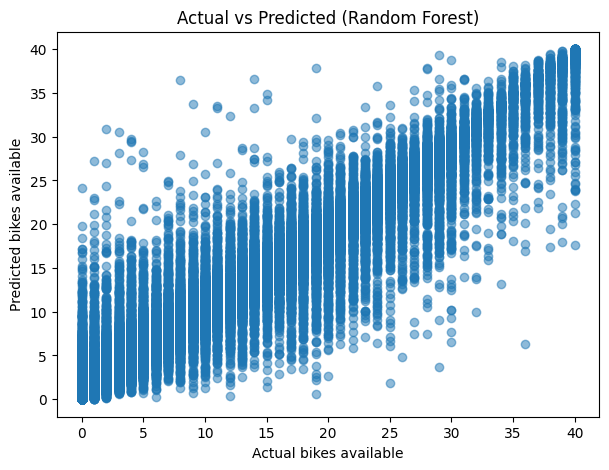

In [133]:
best_pred = best_model.predict(X_test)

plt.figure(figsize=(7, 5))
plt.scatter(y_test, best_pred, alpha=0.5)
plt.xlabel("Actual bikes available")
plt.ylabel("Predicted bikes available")
plt.title(f"Actual vs Predicted ({best_model_name})")
plt.show()

## 16. Feature importance (for tree-based models)

This is useful if your best model is a Decision Tree or Random Forest.

,Feature,Importance
4,lat,0.179256
5,lon,0.162970
8,max_air_temperature_celsius,0.158713
6,day_of_week,0.131728
1,hour,0.127921
10,max_relative_humidity_percent,0.110349
0,station_id,0.090067
9,air_temperature_std_deviation,0.032316
7,rush_hour,0.006681
2,month,0.000000


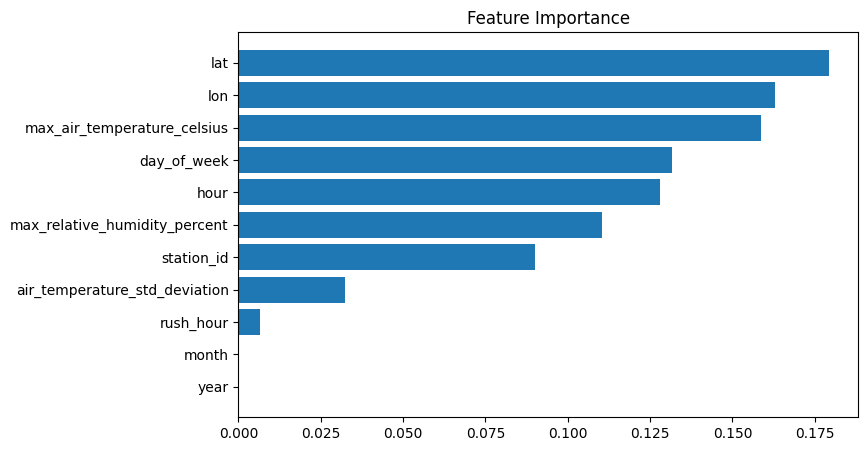

In [134]:
if hasattr(best_model, "feature_importances_"):
    importances = pd.DataFrame({
        "Feature": features,
        "Importance": best_model.feature_importances_
    }).sort_values(by="Importance", ascending=False)

    display(importances)

    plt.figure(figsize=(8, 5))
    plt.barh(importances["Feature"], importances["Importance"])
    plt.gca().invert_yaxis()
    plt.title("Feature Importance")
    plt.show()
else:
    print("Best model does not provide feature_importances_.")

## 17. Save the best model

In [136]:
import os

with open("best_bike_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

print("Saved as best_bike_model.pkl")
print(os.getcwd())

Saved as best_bike_model.pkl
/Users/xiya
